In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
import scipy.stats as stats
import scipy.optimize
import numpy as np
import qng
import math
import matplotlib as mpl
import matplotlib.pyplot as plt

In [6]:
%matplotlib inline

In [2]:
stats.poisson.cdf(12,10.0)

0.79155647639487325

In [3]:
stats.poisson.ppf(0.95,10.0)

15.0

In [4]:
stats.poisson.cdf(15,10.0)

0.95125959669602123

In [5]:
range(1,5)

range(1, 5)

In [6]:
print(range(1,5))

range(1, 5)


In [10]:
for i in range(2,10):
    print (i)

2
3
4
5
6
7
8
9


In [8]:
import qng

In [9]:
qng.erlangB(5.0,6)

0.19184725888636478

In [10]:
qng.erlangB_rec(5.0,6)

0.19184725888636506

In [16]:
%timeit -n 10000 qng.erlangB(15.0,20)

10000 loops, best of 3: 354 µs per loop


In [17]:
%timeit -n 10000 qng.erlangB_rec(15.0,20)

10000 loops, best of 3: 5.06 µs per loop


In [20]:
%timeit -n 10000 qng.poissoninv(0.95,20)

10000 loops, best of 3: 241 µs per loop


In [3]:
arr_rate = 6
svc_rate = 3
c = 3
rho = arr_rate / (svc_rate * c)
load = arr_rate / svc_rate
print(arr_rate,svc_rate,c,rho,load)

6 3 3 0.6666666666666666 2.0


In [4]:
qng.mmc_prob_n(0, arr_rate, svc_rate, c)

0.1111111111111111

In [5]:
1/9

0.1111111111111111

In [3]:
pbar = np.ones(c)

In [4]:
for j in range(1,c):
    pbar[j] = arr_rate * pbar[j-1] / (j * svc_rate)

In [5]:
pbar

array([ 1.        ,  2.5       ,  3.125     ,  2.60416667])

In [6]:
sum(pbar)

9.2291666666666661

In [8]:
gamma = sum(pbar) + rho * pbar[c-1] / (1 - rho)
print(gamma)

13.5694444444


In [15]:
max(0,5)

5

In [6]:
qng.mmc_mean_qwait(arr_rate, svc_rate, c)

0.14814814814814811

In [7]:
arr_rate/(svc_rate * c)

0.6666666666666666

In [9]:
qng.mmc_waitq_cdf(0.14814814814814811,arr_rate, svc_rate, c)

0.71503093847557575

In [10]:
qng.mmc_waitq_cdf(0.5, arr_rate, svc_rate, c)

0.90083103993403124

In [11]:
p = -1
t = 0.1
p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)

while p < 0.95:
    p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)
    print(p,t)
    t = t + 0.1
    

0.670747457475 0.1
0.756083717292 0.2
0.819302373449 0.30000000000000004
0.866135905817 0.4
0.900831039934 0.5
0.926533827457 0.6
0.945574920776 0.7
0.959680909649 0.7999999999999999


In [12]:
p = -1
t = 0.7282
p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)

while p < 0.95:
    p = qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c)
    print(p,t)
    t = t + 0.00001
    
    

0.949989896112 0.7282
0.949991396393 0.7282099999999999
0.949992896629 0.7282199999999999
0.949994396819 0.7282299999999998
0.949995896965 0.7282399999999998
0.949997397065 0.7282499999999997
0.949998897121 0.7282599999999997
0.950000397132 0.7282699999999996


In [13]:
def find_pctile(t, p, arr_rate, svc_rate, c):
    return qng.mmc_waitq_cdf(t, arr_rate, svc_rate, c) - p

In [14]:
p = 0.95
scipy.optimize.newton(find_pctile,0.5,args=(p, arr_rate, svc_rate, c))

0.72826735244588692

In [15]:
qng.mmc_waitq_pctile(p,arr_rate, svc_rate, c)

0.72826735244589413

In [22]:
qng.mm1_waitq_cdf(1.0,barber_arr, barber_svc)

0.693433799023798

In [25]:
qng.mmc_waitq_cdf(1.0,barber_arr, barber_svc, barber_c)

0.69343379902379798

In [17]:
qng.mmc_waitq_pctile(p,arr_rate, c * svc_rate, 1)

0.86342238848194153

In [18]:
barber_arr = 5
barber_svc = 6
barber_c = 1

In [20]:
qng.mmc_mean_qsize(barber_arr, barber_svc, barber_c)

4.1666666666666679

In [23]:
qng.mm1_waitq_pctile(0.9,barber_arr, barber_svc)

2.1202635362000914

In [24]:
qng.mm1_waitq_cdf(2.1202635362000914,barber_arr, barber_svc)

0.9

In [28]:
5/6 * math.exp(-1.0)

0.30656620097620196

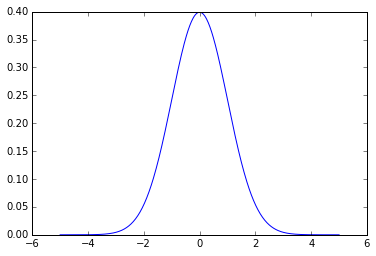

In [7]:
x = np.linspace(-5, 5, 500)
plt.plot(x, stats.norm.pdf(x))

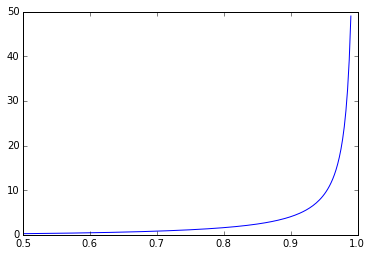

In [12]:
rho = np.linspace(0.5, .99, 200)
plt.plot(rho, qng.mg1_mean_qsize(rho,1,1))

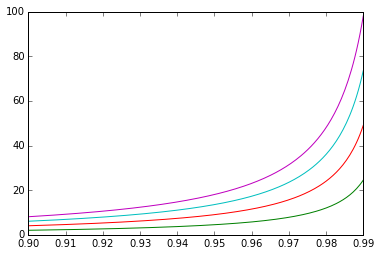

In [16]:
rho = np.linspace(0.9, .99, 200)
for cv2 in np.linspace(0, 2, 5):
    plt.plot(rho, qng.mg1_mean_qsize(rho,1,cv2))

ValueError: setting an array element with a sequence.

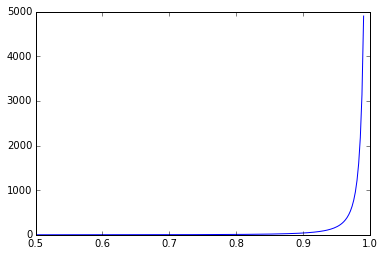

In [18]:
rho = np.linspace(0.5, .99, 200)
for c in [1, 2, 4, 8, 16, 32, 64, 128]:
    load = rho * c
    plt.plot(rho, qng.mmc_mean_qsize(load, 1, c))